# Preliminary Statistical Analysis: Google Trends Data

This notebook provides a first-pass statistical analysis of `google_trends_data.csv`:
- data loading and quality checks,
- descriptive statistics,
- distribution and time-series visualizations,
- simple temporal dependence diagnostics.

In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

In [13]:
data_candidates = [
    Path("../data/equity_data/google_trends_data.csv"),
    Path("data/equity_data/google_trends_data.csv"),
]

data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not locate google_trends_data.csv from current working directory.")

df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["trends_score"] = pd.to_numeric(df["trends_score"], errors="coerce")
df = df.sort_values("date").reset_index(drop=True)

print(f"Data source: {data_path}")
print(f"Rows: {len(df):,}, Columns: {len(df.columns)}")
display(df.head())

Data source: ..\data\equity_data\google_trends_data.csv
Rows: 1,096, Columns: 2


,date,trends_score
0,2023-01-01,40
1,2023-01-02,48
2,2023-01-03,62
3,2023-01-04,73
4,2023-01-05,64


In [14]:
quality_report = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique(dropna=True),
    }
)

date_range = (df["date"].min(), df["date"].max())
duplicate_rows = int(df.duplicated().sum())
duplicate_dates = int(df["date"].duplicated().sum())

full_calendar = pd.date_range(start=date_range[0], end=date_range[1], freq="D")
missing_dates = full_calendar.difference(df["date"].dropna())

display(quality_report)
print(f"Date range: {date_range[0].date()} -> {date_range[1].date()}")
print(f"Duplicate rows: {duplicate_rows}")
print(f"Duplicate dates: {duplicate_dates}")
print(f"Missing calendar dates: {len(missing_dates)}")

if len(missing_dates) > 0:
    print("First missing dates:", [d.date() for d in missing_dates[:10]])

,dtype,missing_values,missing_pct,unique_values
date,datetime64[us],0,0.0,1096
trends_score,int64,0,0.0,69


Date range: 2023-01-01 -> 2025-12-31
Duplicate rows: 0
Duplicate dates: 0
Missing calendar dates: 0


In [15]:
percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
base_stats = df["trends_score"].describe(percentiles=percentiles).to_frame(name="value")

extra_stats = pd.Series(
    {
        "variance": df["trends_score"].var(),
        "IQR": df["trends_score"].quantile(0.75) - df["trends_score"].quantile(0.25),
        "skewness": df["trends_score"].skew(),
        "kurtosis": df["trends_score"].kurt(),
        "coef_of_variation": df["trends_score"].std() / df["trends_score"].mean(),
    },
    name="value",
)

stats_table = pd.concat([base_stats, extra_stats.to_frame()]).round(3)
display(stats_table)

,value
count,1096.000
mean,50.923
std,14.839
min,24.000
1%,25.000
5%,28.000
25%,38.000
50%,52.000
75%,62.000
95%,73.000


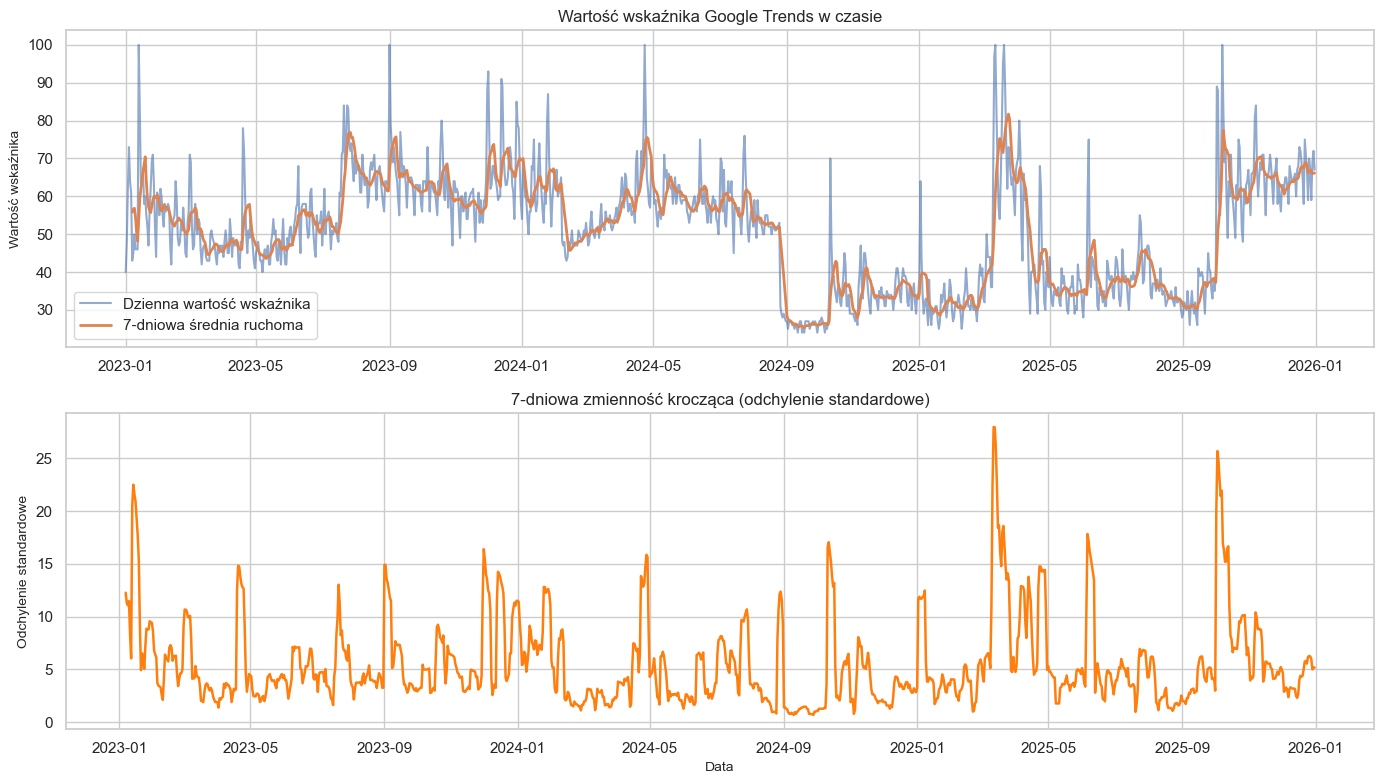

In [16]:
rolling_window = 7
df["rolling_mean_7d"] = df["trends_score"].rolling(rolling_window).mean()
df["rolling_std_7d"] = df["trends_score"].rolling(rolling_window).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(df["date"], df["trends_score"], label="Dzienna wartość wskaźnika", alpha=0.6)
axes[0].plot(df["date"], df["rolling_mean_7d"], label="7-dniowa średnia ruchoma", linewidth=2)
axes[0].set_title("Wartość wskaźnika Google Trends w czasie")
axes[0].set_ylabel("Wartość wskaźnika")
axes[0].legend()

axes[1].plot(df["date"], df["rolling_std_7d"], color="tab:orange", linewidth=1.8)
axes[1].set_title("7-dniowa zmienność krocząca (odchylenie standardowe)")
axes[1].set_ylabel("Odchylenie standardowe")
axes[1].set_xlabel("Data")

plt.tight_layout()
plt.show()

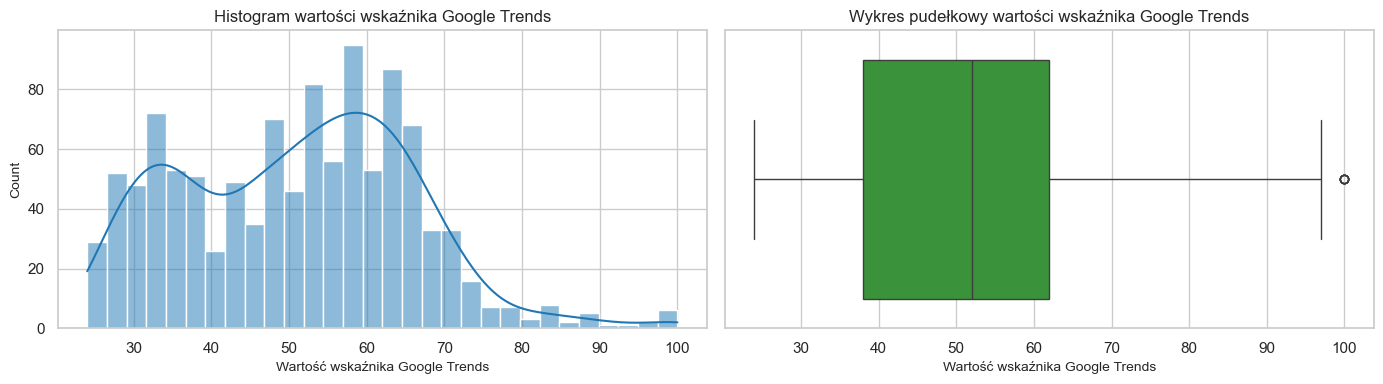

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["trends_score"], bins=30, kde=True, ax=axes[0], color="tab:blue")
axes[0].set_title("Histogram wartości wskaźnika Google Trends")
axes[0].set_xlabel("Wartość wskaźnika Google Trends")

sns.boxplot(x=df["trends_score"], ax=axes[1], color="tab:green")
axes[1].set_title("Wykres pudełkowy wartości wskaźnika Google Trends")
axes[1].set_xlabel("Wartość wskaźnika Google Trends")

plt.tight_layout()
plt.show()

,count,mean,median,std,min,max
weekday,,,,,,
Monday,157,50.96,53.0,13.73,25,84
Tuesday,157,52.46,54.0,15.13,24,100
Wednesday,157,53.29,55.0,15.72,24,100
Thursday,156,53.40,54.5,15.40,26,100
Friday,156,53.68,54.5,15.68,26,100
Saturday,156,47.82,50.0,13.51,26,83
Sunday,157,44.87,47.0,12.31,24,74


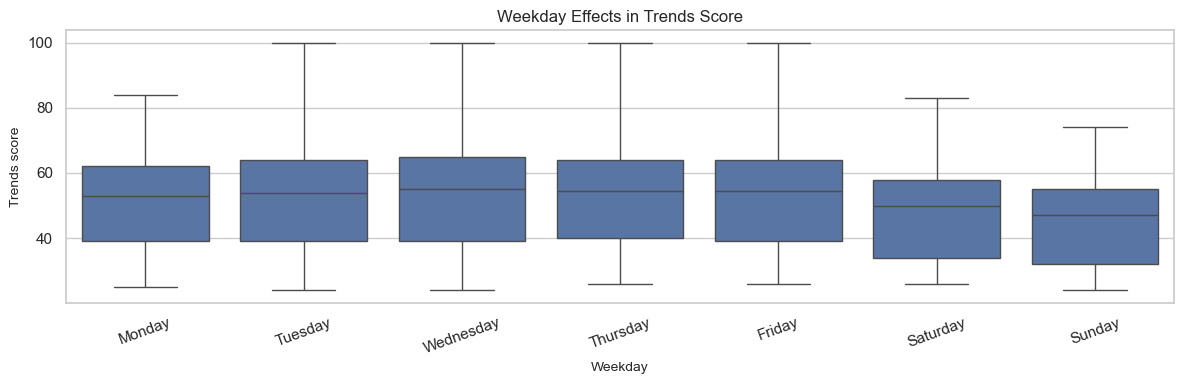

In [18]:
df["weekday"] = df["date"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_summary = (
    df.groupby("weekday")["trends_score"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reindex(weekday_order)
    .round(2)
)
display(weekday_summary)

plt.figure(figsize=(12, 4))
sns.boxplot(data=df, x="weekday", y="trends_score", order=weekday_order)
plt.title("Weekday Effects in Trends Score")
plt.xlabel("Weekday")
plt.ylabel("Trends score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

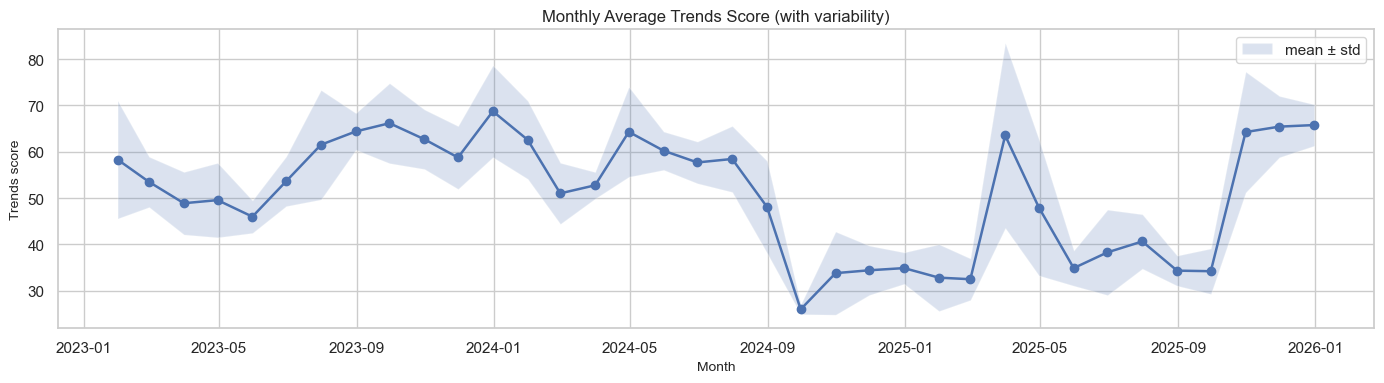

In [22]:
monthly_summary = (
    df.set_index("date")["trends_score"]
    .resample("ME")
    .agg(["mean", "median", "std", "min", "max", "count"])
    .round(2)
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_summary.index, monthly_summary["mean"], marker="o", linewidth=1.8)
ax.fill_between(
    monthly_summary.index,
    monthly_summary["mean"] - monthly_summary["std"].fillna(0),
    monthly_summary["mean"] + monthly_summary["std"].fillna(0),
    alpha=0.2,
    label="mean ± std",
)
ax.set_title("Monthly Average Trends Score (with variability)")
ax.set_xlabel("Month")
ax.set_ylabel("Trends score")
ax.legend()
plt.tight_layout()
plt.show()

,autocorrelation
1,0.883734
2,0.771171
3,0.725778
4,0.714167
5,0.712225
6,0.735185
7,0.759325
8,0.722746
9,0.669823
10,0.644167


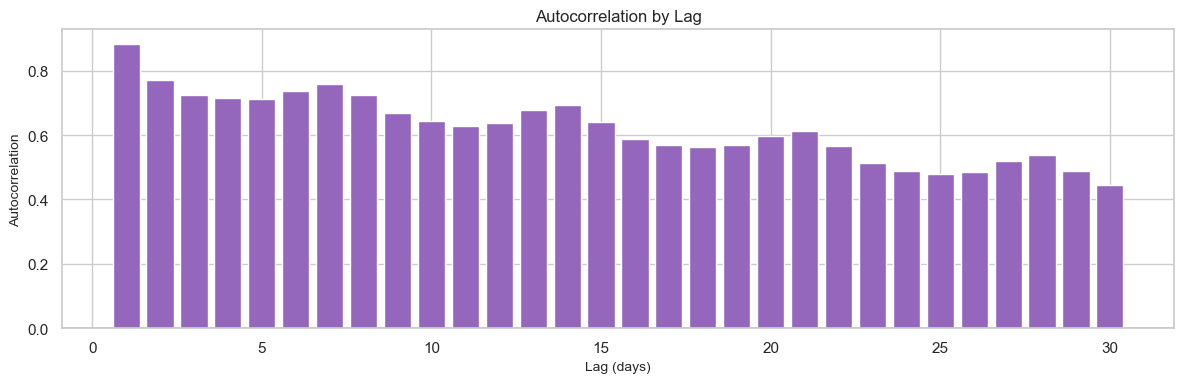

First-difference summary:


,value
count,1095.000
mean,0.025
std,7.156
min,-36.000
25%,-3.000
50%,0.000
75%,3.000
max,54.000


In [20]:
max_lag = 30
autocorr_values = pd.Series(
    {lag: df["trends_score"].autocorr(lag=lag) for lag in range(1, max_lag + 1)},
    name="autocorrelation",
)
display(autocorr_values.head(10).to_frame())

plt.figure(figsize=(12, 4))
plt.bar(autocorr_values.index, autocorr_values.values, color="tab:purple")
plt.axhline(0, color="black", linewidth=1)
plt.title("Autocorrelation by Lag")
plt.xlabel("Lag (days)")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

df["diff_1"] = df["trends_score"].diff()
print("First-difference summary:")
display(df["diff_1"].describe().to_frame(name="value").round(3))

## Preliminary interpretation checklist

After running all cells, summarize:
- whether the series is complete and clean (missing days, duplicates, nulls),
- whether the distribution is symmetric or heavy-tailed,
- whether clear weekday/monthly effects are present,
- whether autocorrelation indicates short-memory structure (useful for forecasting features).

This notebook intentionally stays lightweight and can be extended with formal stationarity tests or decomposition if needed.